In [22]:
!pip install tensorflow==2.20.0 tf-keras==2.20.0 tensorflow-hub==0.16.1


  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 4.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 4.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.2 MB/s  0:00:01
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)

   ---------------------------------------- 0/3 [tensorflow]
   ---------------------------------------- 0/3 [tensorflow]
   ---------------------------------------- 0/3 [tensorflow]
   --------------------

Reason for being yanked: <none given>


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras
import tensorflow_hub as hub

print(tf.__version__)    # should print 2.20.0
print(keras.__version__) # should print 2.20.0
print(hub.__version__)   # should print 0.16.1


2.20.0
2.20.0
0.16.1


In [34]:
df = pd.read_csv("wine-reviews.csv", usecols = ['country', 'description', 'points', 'price', 'variety', 'winery'])

In [35]:
df.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


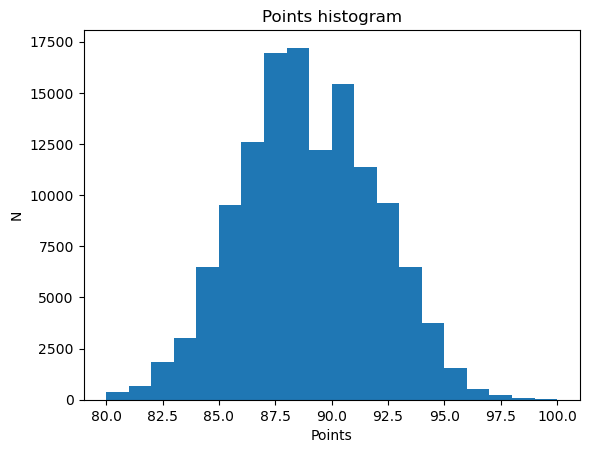

In [36]:
plt.hist(df.points, bins=20)
plt.title("Points histogram")
plt.ylabel("N")
plt.xlabel("Points")
plt.show()

In [37]:
df["label"] = (df.points >= 90).astype(int)
df = df[["description", "label"]]

In [38]:
train, val, test = np.split(df.sample(frac=1), [int(0.8*len(df)), int(0.9*len(df))])

C:\Users\yashwanth\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [39]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('label')
  df = df["description"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

In [40]:
train_data = df_to_dataset(train)
valid_data = df_to_dataset(val)
test_data = df_to_dataset(test)